# Fit of the efficiency

## Preliminaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from numpy.polynomial import chebyshev as C
from numpy.polynomial import legendre as L
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from scipy.stats import chi2

## Definitions

We need to map the kperp domain to the interval [-1, +1] to achieve orthogonality of the Legendre polynomials.

In [2]:
def to_minus1_1(x):
    return 2*(x - xmin)/(xmax - xmin) - 1

def J_to_minus1_1():
    return 2.0 / (xmax - xmin)

## Data as provided by LHCb 2020 (supplementary material)

In [3]:
xmin, xmax, nbins = 0.2, 2.5, 20
bin_edges = np.linspace(xmin, xmax, nbins+1)
x_centres = 0.5*(bin_edges[:-1] + bin_edges[1:])

y = np.array([
    0.0001236531, 0.0001950596, 0.0002130384, 0.0002373194,
    0.0002749433, 0.0002994391, 0.0003263686, 0.0003518466,
    0.0003702397, 0.0003899925, 0.0004229880, 0.0004664168,
    0.0005115563, 0.0005588505, 0.0005949653, 0.0006692885,
    0.0007585226, 0.0008347836, 0.0009775622,
])
yerr = np.array([
    8.296912e-06, 8.590228e-06, 7.750035e-06, 7.239657e-06,
    6.994334e-06, 6.713671e-06, 6.507607e-06, 6.333378e-06,
    6.150770e-06, 6.062810e-06, 6.117261e-06, 6.277558e-06,
    6.521629e-06, 6.842657e-06, 7.190335e-06, 7.961675e-06,
    9.186402e-06, 1.147315e-05, 2.944643e-05
])

x = x_centres[:len(y)]
# map to [-1, 1]
z = to_minus1_1(x)

Weighted least-squares fit

In [4]:
def weighted_fit(z, y, yerr, degree, basis='cheb'):
    if basis == 'cheb':
        Phi = J_to_minus1_1() * np.vstack([C.chebval(z, [0]*k + [1]) for k in range(degree+1)]).T
    elif basis == 'leg':
        Phi = J_to_minus1_1() * np.vstack([L.legval(z, [0]*k + [1]) for k in range(degree+1)]).T
    else:
        raise ValueError("basis must be 'cheb' or 'leg'")
    W = np.diag(1.0 / (yerr**2)) # Weight matrix for chi^2 function
    A = Phi.T @ W @ Phi
    b = Phi.T @ W @ y # weight the linear system
    coeffs = np.linalg.solve(A, b) # Solve for polynomial params Ax = b
    yhat = Phi @ coeffs # predicted efficiencies
    chi2_val = np.sum(((y - yhat)/yerr)**2) # chi-squared measure
    ndof = len(y) - (degree + 1) # dof = no. points - no. fitted params
    p_val = 1 - chi2.cdf(chi2_val, ndof)
    return coeffs, chi2_val, ndof, p_val


In [5]:
degree = 3

coeffs_cheb, chi2_cheb, ndof_cheb, p_val_cheb = weighted_fit(z, y, yerr, degree, basis='cheb')
coeffs_leg,  chi2_leg,  ndof_leg, p_val_leg  = weighted_fit(z, y, yerr, degree, basis='leg')

print(f"Chebyshev: χ² = {chi2_cheb:.2f}, ndof = {ndof_cheb}, p-value = {p_val_cheb:.3f}")
print(f"Chebyshev coeffs : {[f'{c:1.2e}' for c in coeffs_cheb]}")
print(f"Legendre : χ² = {chi2_leg:.2f}, ndof = {ndof_leg}, p-value = {p_val_leg:.3f}")
print(f"Legendre coeffs: {[f'{c:1.2e}' for c in coeffs_leg]}")

Chebyshev: χ² = 19.35, ndof = 15, p-value = 0.198
Chebyshev coeffs : ['5.92e-04', '5.27e-04', '1.18e-04', '6.09e-05']
Legendre : χ² = 19.35, ndof = 15, p-value = 0.198
Legendre coeffs: ['5.53e-04', '4.90e-04', '1.58e-04', '9.74e-05']


## Plot the fit

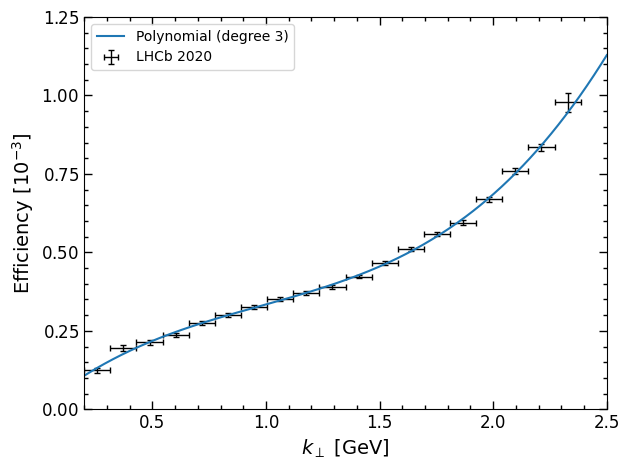

In [6]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator

x_grid = np.linspace(0, 2.5, 400)
z_grid = to_minus1_1(x_grid)

def eval_poly(zv, coeffs, basis):
    return (C.chebval if basis=='cheb' else L.legval)(zv, coeffs)

fig, ax = plt.subplots()

# data points with error bars
ax.errorbar(x, y, yerr=yerr, xerr=0.5*(bin_edges[1]-bin_edges[0]), fmt='None',                    # circular marker
    markersize=4,               # size of marker
    markerfacecolor='white',    # open circle
    markeredgecolor='k',        # black edge
    markeredgewidth=1.0,        # same as line thickness
    ecolor='k',                 # black error bars
    elinewidth=1.0,             # line thickness for error bars
    capsize=2,                  # small cross caps
    label="LHCb 2020"
)

# fitted curves
#ax.plot(x_grid, eval_poly(z_grid, coeffs_cheb, 'cheb'), color='tab:orange', label=f"Chebyshev deg {degree}")
ax.plot(x_grid, J_to_minus1_1() * eval_poly(z_grid, coeffs_leg, 'leg'),
        color='tab:blue', label=f"Polynomial (degree 3)")

# axis labels
ax.set_xlabel(r"$k_\perp$ [GeV]", fontsize = 14)
ax.set_ylabel(r"Efficiency [$10^{-3}$]", fontsize = 14)


# tick styling
ax.tick_params(
    direction='in', top=True, right=True,
    which='both', length=6, width=1, labelsize=12
)
ax.tick_params(which='minor', length=3)

# ----- Major tick spacing -----
ax.set_xlim(0.2, 2.5)                           # ensure range 0 to 2.5
ax.set_ylim(0, 0.00125)                           # ensure range 0 to 2.5
ax.xaxis.set_major_locator(MultipleLocator(0.5))  # major ticks every 0.5
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))   # keep auto spacing on y

# automatic minor ticks between majors
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

#scientific-notation offset, e.g. ×10⁻³ on y–axis
ax.yaxis.get_major_formatter().set_useMathText(True)
ax.yaxis.get_major_formatter().set_powerlimits((-3,-3))
ax.yaxis.offsetText.set_visible(False)

# legend and layout
ax.legend()
fig.tight_layout()
plt.show()

# save as PDF
fig.savefig("figures/efficiency_fit.pdf", format="pdf")
fig.savefig("figures/efficiency_fit.png", format="png")
